In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import pandas as pd
from glaciation_time_estimator.auxiliary_func.config_reader import read_config

In [2]:
phase_pallette = ['#e41a1c', '#377eb8', "#4daf4a"]
config = read_config("/wolke_scratch/dnikolo/Glaciation_time_estimator/configs/2008_tracking/01_02.yaml")

In [ ]:
tracking_data = xr.open_mfdataset('/wolke_scratch/dnikolo/Glac_visualization/20100501.0015_20100515.0000/pixel_path_tracking/20100501.0015_20100515.0000/cloud*.nc', combine='by_coords')

In [4]:
glac_df = pd.read_parquet('/wolke_scratch/dnikolo/Final_results/2010_glac_04.parquet') #pd.read_parquet('/wolke_scratch/dnikolo/Glac_visualization/Analysis_results/Agg_03_Glaciations.parquet')

In [5]:
glac_df=glac_df[~glac_df.is_large_pix_cloud]
glac_df = glac_df[(glac_df.avg_lat >30) | (glac_df.avg_lat<-30)]
lim_glac_df = glac_df[(glac_df["track_start_time"] > "2010-05-01 00:15:00") & (glac_df["track_start_time"] < "2010-05-15 00:00:00") & (glac_df["pole"]=="np") & (glac_df["min_temp"]==-30)]

In [6]:
# (lim_glac_df["avg_size[km]"]>50000).size
len(lim_glac_df[lim_glac_df["avg_size[km]"]>50000])

1

In [7]:
aux_file = xr.open_dataset("/wolke_scratch/dnikolo/CLAAS_Data/np/CM_SAF_CLAAS3_L2_AUX.nc",decode_times=False)
lat_mat = aux_file["lat"].values[0, :, :]
lon_mat = aux_file["lon"].values[0, :, :]

In [8]:
sample_glac = lim_glac_df[lim_glac_df["avg_size[km]"]>50000].sample(1)
def set_glac_properties(sample_glac):
    sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
    sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
    sample_glac["track_end_time"] = sample_glac["track_start_time"]+ sample_glac["track_length"]
set_glac_properties(sample_glac)


In [9]:

# lat_mat[np.isnan(lat_mat)] = np.inf
# lon_mat[np.isnan(lon_mat)] = 0

In [10]:
sample_glac.tracknumber

56165    6878
Name: tracknumber, dtype: int64

In [11]:
print(tracking_data["tracknumber"].max().values)

8043.0


In [12]:
# for _, cloud in sample_glac.iterrows():
# 1) Pull out the cloud sampled glaciation

# print(t)
# for time_ind in range(feat_vals.shape[0]-1):
#     current_image = feat_vals[time_ind]
#     x , y = np.where(current_image==cloud["tracknumber"])
#     if len(x) ==0:
#         print(time_ind,feat_vals.shape[0])
#         # print(x)
        
#     plt.imshow(current_image[x.min():x.max(), y.min():y.max()])


In [13]:
# glac_df[glac_df["tracknumber"]==6952]
glac_df.loc[56172]

Cloud_ID                                                           1589457
Time [m]                                                               120
Magnitude                                                         0.466534
Glac_start_ind                                                           0
Glac_peak_ind                                                            8
Linear                                                                True
line_rmse                                                         0.083562
Rate_arr                 [0.23326681559730456, 0.23326681559730456, 0.2...
Mean_glac_rate                                                    0.233267
Glaciation time [h]                                                    2.0
tracknumber                                                           6952
is_large_pix_cloud                                                   False
is_cot_valid_cloud                                                   False
is_ctp_valid_cloud       

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib import colors as mcolors

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------
cloud_id = 4
# for cloud_id in range(len(sample_glac)):
# cloud = sample_glac.iloc[cloud_id]
cloud = glac_df.loc[56172]
set_glac_properties(cloud)
# 2) Grab its start/end times
t0 = cloud.track_start_time
t1 = cloud.track_end_time 

# 4) Make sure your Dataset’s time coordinate is in datetime64:
#    (optional sanity check)
tracking_data['time'] = tracking_data.indexes['time']
# 5) Slice the Dataset in time and select the right track:
# sub = tracking_data.sel(
#     time=slice(t0, t1)
# )
sub = tracking_data.sel(
    time=slice(t0, t1)
)
# 6) Pull out the feature_number variable
feat_vals = sub['tracknumber'].values
cph_vals = sub["cph_filtered"].values
initial_mat = feat_vals[0]
end_mat = feat_vals[-1]
# print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
t, x,y = np.where(feat_vals==cloud["tracknumber"])





# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# 1) Mask out everything except the target cloud:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# 2) Find the bounding box (over all time steps) of non-NaN pixels:
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# 3) Expand the bounding box by a few pixels:
frame_width = 1
y0 = max(y_min - frame_width, 0)
y1 = min(y_max + 1 + frame_width, H)
x0 = max(x_min - frame_width, 0)
x1 = min(x_max + 1 + frame_width, W)

cropped = cph_vals[:, y0:y1, x0:x1]
cropped_masked = masked_cph[:, y0:y1, x0:x1]
h_crop, w_crop = cropped.shape[1], cropped.shape[2]

# 4) Precompute RGB triplets for the palette
red_rgb   = np.array(mcolors.to_rgb('#e41a1c'))
blue_rgb  = np.array(mcolors.to_rgb('#377eb8'))
green_rgb = np.array(mcolors.to_rgb('#4daf4a'))
white_rgb = np.array([1.0, 1.0, 1.0])

# Function to build an RGB image for a given frame
def make_rgba_frame(frame_idx):
    frame_cph       = cropped[frame_idx]
    frame_cph_cloud = cropped_masked[frame_idx]
    rgb = np.ones((h_crop, w_crop, 3), dtype=float)  # start white

    # Cloud pixels with cph >= 1: interpolate from red to blue
    cloud_mask = ~np.isnan(frame_cph_cloud) & (frame_cph_cloud >= 1)
    if np.any(cloud_mask):
        vals = frame_cph_cloud[cloud_mask]
        t = (vals - 1.0) / 1.0  # normalize 1→0, 2→1
        inter = np.outer(1 - t, red_rgb) + np.outer(t, blue_rgb)
        rgb[cloud_mask] = inter

    # Outside-cloud pixels (i.e., where frame_cph_cloud is NaN) with cph > 1: set green
    outside_mask = np.isnan(frame_cph_cloud) & (frame_cph > 1)
    rgb[outside_mask] = white_rgb#np.array([0,0,0])
    print(rgb.shape)
    return rgb

# 5) Set up the figure with the first frame’s RGB
fig, ax = plt.subplots(figsize=(8, 4))
initial_rgb = make_rgba_frame(0)
im = ax.imshow(initial_rgb, interpolation="none",
            extent=(x0, x1, y1, y0))  # keep original coordinates
ax.set_title(f"Cloud {track_id} CPH Evolution (custom palette)")
ax.axis("off")
i=0
def update(frame):
    current_frame = make_rgba_frame(frame)
    im.set_data(current_frame)
    ax.set_xlabel(f"Time step: {frame}")
    # fig.savefig(f'fig{i}.png')
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=300,   # milliseconds between frames
    blit=True
)
with open(f"/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Tracking_quality_evidence/glaciation_video_{cloud_id}.html", "w") as f:
    print(anim.to_html5_video(), file=f)
# Display inline in Jupyter:
HTML(anim.to_html5_video())

NameError: name 'glac_df' is not defined

/tmp/ipykernel_31038/2339170395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_glac["glaciation_start_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*sample_glac["Glac_start_ind"]
/tmp/ipykernel_31038/2339170395.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_glac["glaciation_end_time"] = sample_glac["track_start_time"]+ pd.Timedelta(minutes=15)*(sample_glac["Glac_peak_ind"]+1)
/tmp/ipykernel_31038/2339170395.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)
(7, 29, 3)


(7, 29, 3)


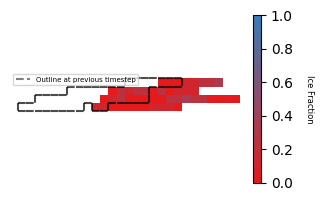

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib import colors as mcolors
import matplotlib.gridspec as gridspec

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------
cloud_id = 4
# for cloud_id in range(len(sample_glac)):
# cloud = sample_glac.iloc[cloud_id]
cloud = glac_df.loc[56172]
set_glac_properties(cloud)
# 2) Grab its start/end times
t0 = cloud.track_start_time
t1 = cloud.track_end_time 

# 4) Make sure your Dataset’s time coordinate is in datetime64:
#    (optional sanity check)
tracking_data['time'] = tracking_data.indexes['time']
# 5) Slice the Dataset in time and select the right track:
# sub = tracking_data.sel(
#     time=slice(t0, t1)
# )
sub = tracking_data.sel(
    time=slice(t0, t1)
)
# 6) Pull out the feature_number variable
feat_vals = sub['tracknumber'].values
cph_vals = sub["cph_filtered"].values
initial_mat = feat_vals[0]
end_mat = feat_vals[-1]
# print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
t, x,y = np.where(feat_vals==cloud["tracknumber"])





# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# 1) Mask out everything except the target cloud:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# 2) Find the bounding box (over all time steps) of non-NaN pixels:
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# 3) Expand the bounding box by a few pixels:
frame_width = 1
y0 = max(y_min - frame_width, 0)
y1 = min(y_max + 1 + frame_width, H)
x0 = max(x_min - frame_width, 0)
x1 = min(x_max + 1 + frame_width, W)

cropped = cph_vals[:, y0:y1, x0:x1]
cropped_masked = masked_cph[:, y0:y1, x0:x1]
h_crop, w_crop = cropped.shape[1], cropped.shape[2]

# 4) Precompute RGB triplets for the palette
red_rgb   = np.array(mcolors.to_rgb('#e41a1c'))
blue_rgb  = np.array(mcolors.to_rgb('#377eb8'))
green_rgb = np.array(mcolors.to_rgb('#4daf4a'))
white_rgb = np.array([1.0, 1.0, 1.0])

# Function to build an RGB image for a given frame
def make_rgba_frame(frame_idx):
    frame_cph       = cropped[frame_idx]
    frame_cph_cloud = cropped_masked[frame_idx]
    rgb = np.ones((h_crop, w_crop, 3), dtype=float)  # start white

    # Cloud pixels with cph >= 1: interpolate from red to blue
    cloud_mask = ~np.isnan(frame_cph_cloud) & (frame_cph_cloud >= 1)
    if np.any(cloud_mask):
        vals = frame_cph_cloud[cloud_mask]
        t = (vals - 1.0) / 1.0  # normalize 1→0, 2→1
        inter = np.outer(1 - t, red_rgb) + np.outer(t, blue_rgb)
        rgb[cloud_mask] = inter

    # Outside-cloud pixels (i.e., where frame_cph_cloud is NaN) with cph > 1: set green
    outside_mask = np.isnan(frame_cph_cloud) & (frame_cph > 1)
    rgb[outside_mask] = white_rgb#np.array([0,0,0])
    print(rgb.shape)
    return rgb

# 5) Set up the figure with the first frame’s RGB
fig = plt.figure(figsize=(5.501, 8.434), constrained_layout=True)
gs = gridspec.GridSpec(10, 6,height_ratios=[0.1,1,0.05,0.1,1,0.05, 1,0.1,1,0.5],width_ratios=[1,1,1,1,1,1],figure=fig)#,hspace=1.2, wspace=0.3)#,# Remove all borders and ticks.
ax = fig.add_subplot(gs[6, :3])

initial_rgb = make_rgba_frame(0)
im = ax.imshow(initial_rgb, interpolation="none",
            extent=(x0, x1, y1, y0))  # keep original coordinates
extent = (x0, x1, y1, y0)   # same as what you passed to imshow

# 2) keep track of the *boolean mask*, not the RGB
previous_mask = None



from matplotlib.lines import Line2D

# lock the zoom and show axes
ax.set_autoscale_on(False)
ax.axis('off')

# draw the first frame
im = ax.imshow(
    make_rgba_frame(0),
    interpolation='none',
    extent=(x0, x1, y0, y1),
    origin='lower'
)
legend_handle = Line2D(
    [0], [0],
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Outline at previous timestep'
)
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
ax.legend(handles=[legend_handle], loc='upper left',fontsize=5)
# 1) Define the same colormap and norm you use in make_rgba_frame:
cmap = LinearSegmentedColormap.from_list('cph_rb',
                                         ['#e41a1c', '#377eb8'])
norm = Normalize(vmin=0.0, vmax=1.0)   # because you interpolate 1→0, 2→1

# 2) Create a ScalarMappable and register its “data range”:
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])    # only needed so colorbar can find the mappable’s range

# 3) After you do your imshow() but before the animation, add the colorbar:
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Ice Fraction', rotation=270, labelpad=15,fontsize=6)
previous_mask = None

def update(frame):
    global previous_mask

    # 1) update the image
    im.set_data(make_rgba_frame(frame))
    ax.set_xlabel(f"Time step: {frame}")

    # 2) clear any old contour‐segments
    #    we’ve been adding Line2D objects, so clear them here:
    for line in list(ax.lines):
        line.remove()

    # 3) if we have a previous mask, build its edge‐segments
    if previous_mask is not None:
        h, w = previous_mask.shape
        segs = []   # list of ((x1,x2), (y1,y2)) pairs

        for r in range(h):
            for c in range(w):
                if not previous_mask[r, c]:
                    continue

                # the pixel in data coords spans x: [x0+c, x0+c+1], y: [y0+r, y0+r+1]
                xL, xR = x0 + c,     x0 + c + 1
                yB, yT = y0 + r,     y0 + r + 1

                # if no neighbor to the left → draw left edge
                if c == 0         or not previous_mask[r, c-1]:
                    segs.append(((xL, xL), (yB, yT)))
                # right edge
                if c == w - 1     or not previous_mask[r, c+1]:
                    segs.append(((xR, xR), (yB, yT)))
                # bottom edge
                if r == 0         or not previous_mask[r-1, c]:
                    segs.append(((xL, xR), (yB, yB)))
                # top edge
                if r == h - 1     or not previous_mask[r+1, c]:
                    segs.append(((xL, xR), (yT, yT)))

        # 4) plot each segment as a Line2D
        for (xs, ys) in segs:
            ax.add_line(Line2D(xs, ys, color='black',alpha=0.7,
            linestyle='--', linewidth=1.5))#,label="Previous frame outline"))

    # 5) prepare for next frame:
    previous_mask = ~np.isnan(cropped_masked[frame])
    # ax.legend()
    return [im]

anim = animation.FuncAnimation(
    fig, update, frames=n_frames, interval=300, blit=False
)

with open(f"/wolke_scratch/dnikolo/Glaciation_time_estimator/Result_analysis/Tracking_quality_evidence/glaciation_video_{cloud_id}.html", "w") as f:
    print(anim.to_html5_video(), file=f)
# Display inline in Jupyter:
HTML(anim.to_html5_video())

In [15]:
plt.plot(cloud["ice_frac_hist"])

NameError: name 'cloud' is not defined

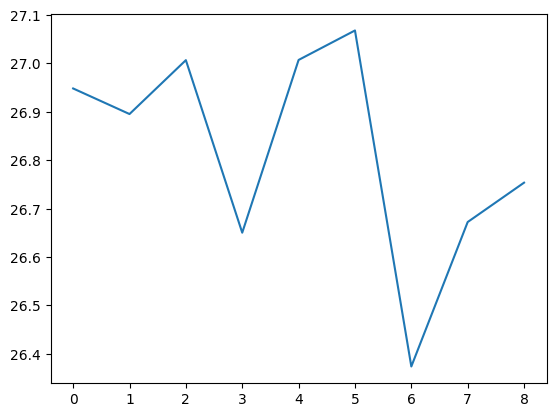

In [17]:
plt.plot(273.15-cloud["ctt_hist"])

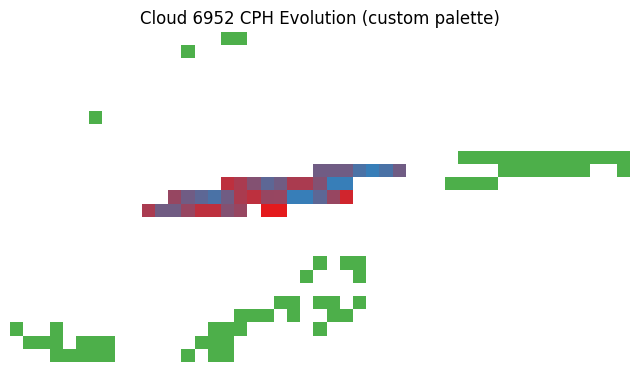

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib import colors as mcolors
from IPython.display import HTML

# --- Assumes these are already in your notebook: ---
# cph_vals : numpy array of shape (n_time, H, W) with values in [0, 2]
# feat_vals: numpy array of shape (n_time, H, W) with track numbers
# cloud    : pandas Series (or dict-like) containing "tracknumber"
# ---------------------------------------------------------

track_id = cloud["tracknumber"]
n_frames, H, W = cph_vals.shape

# 1) Mask out everything except the target cloud:
masked_cph = np.full_like(cph_vals, np.nan, dtype=float)
for t in range(n_frames):
    mask = (feat_vals[t] == track_id)
    masked_cph[t] = np.where(mask, cph_vals[t], np.nan)

# 2) Find the bounding box (over all time steps) of non-NaN pixels:
ys, xs = np.where(np.any(~np.isnan(masked_cph), axis=0))
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# 3) Expand the bounding box by a few pixels:
frame_width = 10
y0 = max(y_min - frame_width, 0)
y1 = min(y_max + 1 + frame_width, H)
x0 = max(x_min - frame_width, 0)
x1 = min(x_max + 1 + frame_width, W)

cropped = cph_vals[:, y0:y1, x0:x1]
cropped_masked = masked_cph[:, y0:y1, x0:x1]
h_crop, w_crop = cropped.shape[1], cropped.shape[2]

# 4) Precompute RGB triplets for the palette
red_rgb   = np.array(mcolors.to_rgb('#e41a1c'))
blue_rgb  = np.array(mcolors.to_rgb('#377eb8'))
green_rgb = np.array(mcolors.to_rgb('#4daf4a'))
white_rgb = np.array([1.0, 1.0, 1.0])

# Function to build an RGB image for a given frame
def make_rgba_frame(frame_idx):
    frame_cph       = cropped[frame_idx]
    frame_cph_cloud = cropped_masked[frame_idx]
    rgb = np.ones((h_crop, w_crop, 3), dtype=float)  # start white

    # Cloud pixels with cph >= 1: interpolate from red to blue
    cloud_mask = ~np.isnan(frame_cph_cloud) & (frame_cph_cloud >= 1)
    if np.any(cloud_mask):
        vals = frame_cph_cloud[cloud_mask]
        t = (vals - 1.0) / 1.0  # normalize 1→0, 2→1
        inter = np.outer(1 - t, red_rgb) + np.outer(t, blue_rgb)
        rgb[cloud_mask] = inter

    # Outside-cloud pixels (i.e., where frame_cph_cloud is NaN) with cph > 1: set green
    outside_mask = np.isnan(frame_cph_cloud) & (frame_cph > 1)
    rgb[outside_mask] = green_rgb

    return rgb

# 5) Set up the figure with the first frame’s RGB
fig, ax = plt.subplots(figsize=(8, 8))
initial_rgb = make_rgba_frame(0)
im = ax.imshow(initial_rgb, interpolation="none",
               extent=(x0, x1, y1, y0))  # keep original coordinates
ax.set_title(f"Cloud {track_id} CPH Evolution (custom palette)")
ax.axis("off")

def update(frame):
    im.set_data(make_rgba_frame(frame))
    ax.set_xlabel(f"Time step: {frame}")
    return [im]

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=300,   # milliseconds between frames
    blit=True
)

# Display inline in Jupyter:
HTML(anim.to_html5_video())


In [19]:
for _, cloud in sample_glac.iterrows():
    # 1) Pull out the cloud sampled glaciation
    # cloud = sample_glac.iloc[9]

    # 2) Grab its start/end times
    t0 = cloud.track_start_time
    t1 = cloud.glaciation_end_time 

    # 4) Make sure your Dataset’s time coordinate is in datetime64:
    #    (optional sanity check)
    tracking_data['time'] = tracking_data.indexes['time']
    # 5) Slice the Dataset in time and select the right track:
    # sub = tracking_data.sel(
    #     time=slice(t0, t1)
    # )
    sub = tracking_data.sel(
        time=slice(t0, t1)
    )
    # 6) Pull out the feature_number variable
    feat_vals = sub['tracknumber'].values
    cph_vals = sub["cph_filtered"].values
    initial_mat = feat_vals[0]
    end_mat = feat_vals[-1]
    # print(len(initial_mat[initial_mat==(cloud["tracknumber"])]), cloud["avg_size[px]"], cloud["min_size[px]"], cloud["max_size[px]"])
    size_change= len(initial_mat[initial_mat==(cloud["tracknumber"])])-len(end_mat[end_mat==(cloud["tracknumber"])])
    t, x,y = np.where(feat_vals==cloud["tracknumber"])


    print(t)
    # for time_ind in range(feat_vals.shape[0]-1):
    #     current_image = feat_vals[time_ind]
    #     x , y = np.where(current_image==cloud["tracknumber"])
    #     if len(x) ==0:
    #         print(time_ind,feat_vals.shape[0])
    #         # print(x)
            
    #     plt.imshow(current_image[x.min():x.max(), y.min():y.max()])

    
    # print(np.count_nonzero( np.isnan(feat_vals)))
    # # print(cloud.track_id, cloud.glaciation_start_time, cloud.glaciation_end_time, cloud.lat_hist[0], cloud.lon_hist[0])
    # diff_mat = np.abs((lat_mat - cloud.lat_hist[0])) + np.abs((lon_mat - cloud.lon_hist[0]))
    # untransformed_init_idx = np.where(diff_mat==np.nanmin(diff_mat))
    # cloud_init_idx = (np.array([int(untransformed_init_idx[0][0]/3)]),np.array([int(untransformed_init_idx[1][0]/3)]))
    # print(cloud_init_idx, untransformed_init_idx)
    # region = feat_vals[0][cloud_init_idx[0][0]-3:cloud_init_idx[0][0]+4, cloud_init_idx[1][0]-3:cloud_init_idx[1][0]+4]
    # print(region)
    # print(np.unique(region))

[ 0  0  0 ... 35 35 35]


In [20]:
plt.imshow( region)
plt.colorbar()

NameError: name 'region' is not defined

In [ ]:
diff_mat

array([[ 49.09272817,  49.09272817,  49.09272817, ...,  49.09272817,
         49.09272817,  49.09272817],
       [ 49.09272817,  49.09272817,  49.09272817, ...,  49.09272817,
         49.09272817,  49.09272817],
       [ 49.09272817,  49.09272817,  49.09272817, ...,  49.09272817,
         49.09272817,  49.09272817],
       ...,
       [ 49.09272817, 133.26361587, 131.98847453, ..., 157.93725236,
         49.09272817,  49.09272817],
       [ 49.09272817, 132.38805242, 131.45515588, ..., 157.06179686,
         49.09272817,  49.09272817],
       [132.90893869, 131.77152705, 130.99614073, ..., 156.4453059 ,
        157.58262605,  49.09272817]])

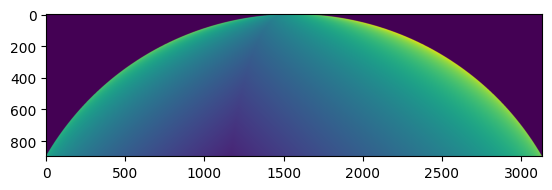

In [ ]:
plt.imshow(diff_mat)
plt.show()

In [ ]:
np.argmin((lat_mat - cloud.lat_hist[0]) + (lon_mat - cloud.lon_hist[0]),keepdims=True)


array([[2769578]])

In [ ]:
feat_vals.max()

2278.0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# For the demo, generate dummy feat_vals if not already defined
# Remove or replace this line with your real feat_vals array.
# feat_vals = np.random.rand(50, 10, 10)  

fig, ax = plt.subplots()
# Initialize the image with zeros and set vmin/vmax
im = ax.imshow(np.zeros_like(feat_vals[0]), vmin=1,vmax=168, aspect='equal',cmap='viridis')
ax.set_title("Feature Number Heatmap")

def init():
    im.set_data(np.zeros_like(feat_vals[0]))
    return (im,)

def animate(i):
    im.set_data(feat_vals[i])
    return (im,)

# Create the animation
anim = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=feat_vals.shape[0], interval=200, blit=True
)

plt.close(fig)  # Prevent duplicate static plot display
HTML(anim.to_jshtml())


Error in callback <function _draw_all_if_interactive at 0x7f56ae7bccc0> (for post_execute):


AttributeError: AxesImage.set() got an unexpected keyword argument 'square'

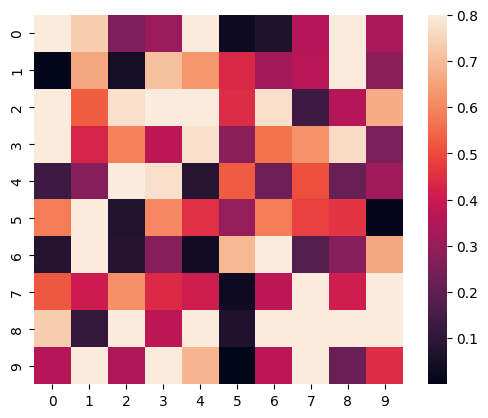

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import animation
# %matplotlib ipympl
fig = plt.figure()
data = np.random.rand(10, 10)
sns.heatmap(data, vmax=.8, square=True)

def init():
    plt.imshow(np.zeros(feat_vals.shape[1:]), vmax=.8, square=True, cbar=False)

def animate(i):
    # data = np.random.rand(10, 10)
    plt.imshow(feat_vals[i,:,:], vmax=.8, square=True, cbar=False)

anim = animation.FuncAnimation(fig, animate, init_func=init, frames=feat_vals.shape[0], repeat = False)

In [ ]:
import numpy as np
import pandas as pd

# 1. get your start
start = pd.to_datetime(sample_glac.iloc[0]["glaciation_start_time"])

# 2. (optional) strip any timezone info so the dtypes match
start = start.tz_localize(None)

# 3. pull out the numpy array of times
time_arr = tracking_data.time.values  # this is an array of numpy.datetime64

# 4a. for an *exact* lookup (may still KeyError if not present):
try:
    idx_exact = tracking_data.time.to_index().get_loc(start)
except KeyError:
    idx_exact = None

# 4b. for the *nearest* match:
idx_nearest = np.argmin(np.abs(time_arr - np.datetime64(start)))

# 5. choose whichever index you want
index_to_use = idx_exact if idx_exact is not None else idx_nearest

# 6. isel by that integer
feat = tracking_data["feature_number"].isel(time=index_to_use)


In [ ]:
print(idx_nearest)

395


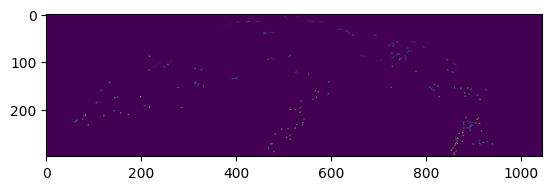

In [ ]:
plt.imshow(feat)

In [ ]:
tracking_data["feature_number"].isel(time=)

SyntaxError: invalid syntax (1001145380.py, line 1)

In [ ]:
sample_glac.keys()

Index(['Cloud_ID', 'Time [m]', 'Magnitude', 'Glac_start_ind', 'Glac_peak_ind',
       'Linear', 'line_rmse', 'Rate_arr', 'Mean_glac_rate',
       'Glaciation time [h]', 'is_large_pix_cloud', 'is_cot_valid_cloud',
       'is_ctp_valid_cloud', 'is_liq', 'is_mix', 'is_ice', 'max_water_frac',
       'max_ice_fraction', 'avg_size[km]', 'max_size[km]', 'min_size[km]',
       'avg_size[px]', 'max_size[px]', 'min_size[px]', 'track_start_time',
       'track_length', 'avg_cot', 'avg_ctp', 'glaciation_start_time',
       'glaciation_end_time', 'avg_lat', 'avg_lon', 'start_ice_fraction',
       'end_ice_fraction', 'ice_frac_hist', 'cot_hist', 'cot_nan_frac_hist',
       'ctp_hist', 'ctp_nan_frac_hist', 'lat_hist', 'lon_hist', 'size_hist_km',
       'min_temp', 'max_temp', 'pole', 'Hemisphere', 'Lifetime [h]'],
      dtype='object')

Text(0.5, 1.0, 'Sample Glacier Ice Fraction Over Time')

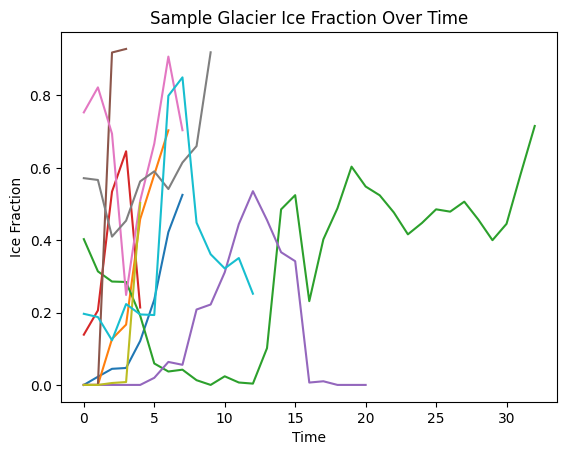

In [ ]:
for glac_if_hist in sample_glac["ice_frac_hist"].values:
    plt.plot(glac_if_hist)
    
    # plt.legend()
    # plt.show()
# plt.plot(a.values[0])
plt.xlabel("Time")
plt.ylabel("Ice Fraction")
plt.title("Sample Glacier Ice Fraction Over Time")